# DataLab II  2025-26

# Sprint 2 – European Soccer Database
---
| | |
|---|---|
| **Klas/Groep** | B2 |
| **Datum** | 03-03-2025 |
| **Gekozen club** | AZ Alkmaar |
| **Competitie** | [Vul in] |
| **Seizoen** | [Vul in] |

---
## Inhoudsopgave
1. [Imports & Configuratie](#1)
2. [Data laden & beschrijven](#2)
3. [Club identifiers bepalen](#3)
4. [Ranglijst seizoen](#4)
5. [Voorspellend model](#5)
6. [Advies technisch directeur](#6)
7. [Retrospective & GenAI-evaluatie](#7)

---
<a id='1'></a>
## 1. Imports & Configuratie

In [2]:
# Imports

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Constanten (DB_PATH, CLUB_NAME, SEASON, etc.)

---
<a id='2'></a>
## 2. Data laden & beschrijven
> Laad de data uit de SQL-database en beschrijf de tabellen en hun relaties.

In [ ]:
import kaggle 

kaggle.api.authenticate()
kaggle.api.dataset_download_files("hugomathien/soccer", path='.', unzip=True)


Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer


In [12]:
connection = sqlite3.connect("database.sqlite")

df = pd.read_sql("""
    
    SELECT *  
        FROM Match 
                 
    """, connection)

df.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [15]:
# Query om alle tabelnamen uit de database te halen
query_tables = """
    SELECT name 
    FROM sqlite_master 
    WHERE type='table';
"""

# Lees de resultaten in een pandas DataFrame
tables_df = pd.read_sql(query_tables, connection)

# Laat de lijst met tabellen zien
print("Tabellen in de database:")
print(tables_df)

Tabellen in de database:
                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes


In [17]:
# Query
query_az_teams = """
    SELECT * FROM Team 
    WHERE team_long_name LIKE '%AZ%' 
       OR team_short_name LIKE '%AZ%';
"""
az_teams_df = pd.read_sql(query_az_teams, connection)

print("Gevonden teams met 'AZ' in de naam:")
display(az_teams_df) 

Gevonden teams met 'AZ' in de naam:


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,20516,8543,46,Lazio,LAZ
1,26563,10229,1906,AZ,ALK


In [ ]:
# Query
query_eredivisie = """
SELECT 
    Match.date,
    Match.season,
    HT.team_long_name AS thuisteam,
    AT.team_long_name AS uitteam,
    Match.home_team_goal AS thuis_doelpunten,
    Match.away_team_goal AS uit_doelpunten
FROM Match
JOIN League ON Match.league_id = League.id
JOIN Country ON League.country_id = Country.id
JOIN Team AS HT ON Match.home_team_api_id = HT.team_api_id
JOIN Team AS AT ON Match.away_team_api_id = AT.team_api_id
WHERE Country.name = 'Netherlands' AND Match.season = '2015/2016' 
ORDER BY Match.date;
"""

df_eredivisie = pd.read_sql_query(query_eredivisie, connection)

print("Eerste 5 wedstrijden van dit seizoen:")
print(df_eredivisie.head())

Eerste 5 wedstrijden van dit seizoen:
                  date     season         thuisteam          uitteam  \
0  2015-08-08 00:00:00  2015/2016  Roda JC Kerkrade  Heracles Almelo   
1  2015-08-08 00:00:00  2015/2016         Feyenoord       FC Utrecht   
2  2015-08-09 00:00:00  2015/2016                AZ             Ajax   
3  2015-08-09 00:00:00  2015/2016         Willem II          Vitesse   
4  2015-08-11 00:00:00  2015/2016     SC Heerenveen    De Graafschap   

   thuis_doelpunten  uit_doelpunten  
0                 3               1  
1                 3               2  
2                 0               3  
3                 1               1  
4                 3               1  


In [20]:
# 1. Bepaal wie de wedstrijd wint en deel de punten uit
condities = [
    df_eredivisie['thuis_doelpunten'] > df_eredivisie['uit_doelpunten'],  # Thuisteam wint
    df_eredivisie['thuis_doelpunten'] == df_eredivisie['uit_doelpunten']  # Gelijkspel
]

# Punten voor thuisploeg: 3 bij winst, 1 bij gelijkspel, anders 0
df_eredivisie['punten_thuis'] = np.select(condities, [3, 1], default=0)

# Punten voor uitploeg: 0 bij verlies, 1 bij gelijkspel, anders 3
df_eredivisie['punten_uit'] = np.select(condities, [0, 1], default=3)

# 2. Verzamel alle behaalde thuispunten per team
thuis_tabel = df_eredivisie.groupby('thuisteam')['punten_thuis'].sum().reset_index()
thuis_tabel.columns = ['Team', 'Punten'] # Kolomnamen netjes maken

# 3. Verzamel alle behaalde uitpunten per team
uit_tabel = df_eredivisie.groupby('uitteam')['punten_uit'].sum().reset_index()
uit_tabel.columns = ['Team', 'Punten']

# 4. Voeg thuis en uit samen, tel het totaal op en maak de ranglijst
alle_punten = pd.concat([thuis_tabel, uit_tabel])
eindstand = alle_punten.groupby('Team')['Punten'].sum().reset_index()

# Sorteer van meeste naar minste punten
eindstand = eindstand.sort_values(by='Punten', ascending=False).reset_index(drop=True)

# Visueel trucje: laat de lijst bij 1 beginnen (positie 1) in plaats van 0
eindstand.index = eindstand.index + 1

print("Eindstand Eredivisie Seizoen:")
print(eindstand)

Eindstand Eredivisie Seizoen:
                Team  Punten
1                PSV      84
2               Ajax      82
3          Feyenoord      63
4                 AZ      59
5         FC Utrecht      53
6    Heracles Almelo      51
7       FC Groningen      50
8         PEC Zwolle      48
9            Vitesse      46
10            N.E.C.      46
11      ADO Den Haag      43
12         FC Twente      43
13     SC Heerenveen      42
14  Roda JC Kerkrade      34
15         Excelsior      30
16         Willem II      29
17     De Graafschap      23
18        SC Cambuur      18


In [22]:
def haal_club_ids_op(club_naam, conn):
    """
    Zoekt een club op basis van de naam. Kijkt eerst naar een exacte match,
    en zoekt daarna eventueel breder. Retourneert de API en FIFA ID's.
    """
    # 1. Probeer eerst een EXACTE match (veilig met parameters wegens eventuele aanhalingstekens)
    query_exact = "SELECT team_api_id, team_fifa_api_id, team_long_name FROM Team WHERE team_long_name = ?;"
    df = pd.read_sql_query(query_exact, conn, params=(club_naam,))
    
    # 2. Als exacte match leeg is, probeer dan een brede zoekopdracht met LIKE
    if df.empty:
        # Voor de LIKE query plakken we de % wildcards rondom de zoekterm
        zoek_term = f"%{club_naam}%"
        query_breed = "SELECT team_api_id, team_fifa_api_id, team_long_name FROM Team WHERE team_long_name LIKE ?;"
        df = pd.read_sql_query(query_breed, conn, params=(zoek_term,))

    if not df.empty:
        # Pak de ID's van de eerste regel
        api_id = df.iloc[0]['team_api_id']
        fifa_id = df.iloc[0]['team_fifa_api_id']
        gevonden_naam = df.iloc[0]['team_long_name']
        
        print(f"ID's gevonden voor: {gevonden_naam}")
        return api_id, fifa_id
    else:
        print(f"Club '{club_naam}' niet gevonden.")
        return None, None

# Roep de functie aan met de 'connection' variabele die we in de eerste stap hebben aangemaakt
AZ_API_ID, AZ_FIFA_ID = haal_club_ids_op("AZ", connection)

print(f"Opgeslagen constante AZ_API_ID: {AZ_API_ID}")
print(f"Opgeslagen constante AZ_FIFA_ID: {AZ_FIFA_ID}")

ID's gevonden voor: AZ
Opgeslagen constante AZ_API_ID: 10229
Opgeslagen constante AZ_FIFA_ID: 1906



Top 5 Eredivisie (2015/2016):
         Team  Punten
1         PSV      84
2        Ajax      82
3   Feyenoord      63
4          AZ      59
5  FC Utrecht      53


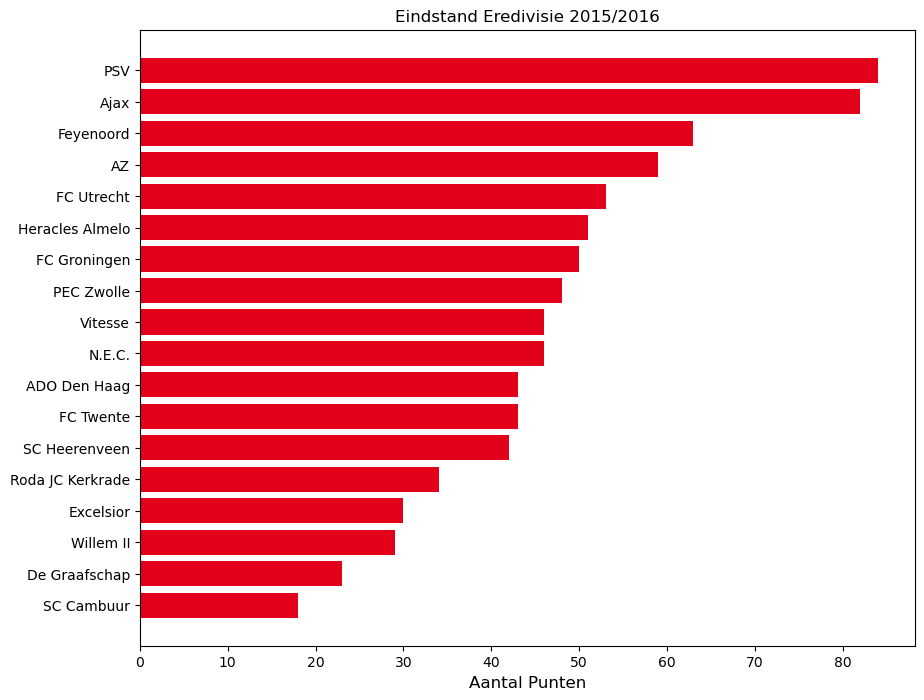

In [ ]:
def haal_wedstrijden_op(seizoen, land_naam, db_pad):
    """Haalt alle wedstrijden van een specifiek seizoen en land op."""
    conn = sqlite3.connect(db_pad)
    query = f"""
    SELECT 
        HT.team_long_name AS thuisteam,
        AT.team_long_name AS uitteam,
        Match.home_team_goal AS thuis_doelpunten,
        Match.away_team_goal AS uit_doelpunten
    FROM Match
    JOIN League ON Match.league_id = League.id
    JOIN Country ON League.country_id = Country.id
    JOIN Team AS HT ON Match.home_team_api_id = HT.team_api_id
    JOIN Team AS AT ON Match.away_team_api_id = AT.team_api_id
    WHERE Country.name = '{land_naam}' AND Match.season = '{seizoen}';
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def bereken_en_sorteer_stand(df_wedstrijden):
    """Berekent de eindstand (3 punten voor winst, 1 voor gelijk) en sorteert deze."""
    condities = [
        df_wedstrijden['thuis_doelpunten'] > df_wedstrijden['uit_doelpunten'],
        df_wedstrijden['thuis_doelpunten'] == df_wedstrijden['uit_doelpunten']
    ]

    df_wedstrijden['punten_thuis'] = np.select(condities, [3, 1], default=0)
    df_wedstrijden['punten_uit'] = np.select(condities, [0, 1], default=3)

    thuis_tabel = df_wedstrijden.groupby('thuisteam')['punten_thuis'].sum().reset_index()
    thuis_tabel.columns = ['Team', 'Punten']
    
    uit_tabel = df_wedstrijden.groupby('uitteam')['punten_uit'].sum().reset_index()
    uit_tabel.columns = ['Team', 'Punten']

    alle_punten = pd.concat([thuis_tabel, uit_tabel])
    eindstand = alle_punten.groupby('Team')['Punten'].sum().reset_index()
    eindstand = eindstand.sort_values(by='Punten', ascending=False).reset_index(drop=True)
    
    eindstand.index = eindstand.index + 1 
    
    return eindstand

# Uitvoering & Visualisatie
# Definieer het pad naar je database
DB_PAD = "database.sqlite" 

df_eredivisie = haal_wedstrijden_op('2015/2016', 'Netherlands', DB_PAD)
eindstand_eredivisie = bereken_en_sorteer_stand(df_eredivisie)

print("\nTop 5 Eredivisie (2015/2016):")
print(eindstand_eredivisie.head())

plt.figure(figsize=(10, 8))
plt.barh(eindstand_eredivisie['Team'][::-1], eindstand_eredivisie['Punten'][::-1], color='#e3001b')
plt.xlabel('Aantal Punten', fontsize=12)
plt.title('Eindstand Eredivisie 2015/2016')
plt.show()

### Relaties tussen tabellen

| Tabel A | Sleutel A | Tabel B | Sleutel B | Relatie |
|---|---|---|---|---|
| Match | home_team_api_id | Team | team_api_id | N:1 |
| Match | away_team_api_id | Team | team_api_id | N:1 |
| Match | league_id | League | id | N:1 |
| Match | country_id | Country | id | N:1 |
| Team_Attributes | team_api_id | Team | team_api_id | N:1 |
| Player_Attributes | player_api_id | Player | player_api_id | N:1 |

> **Toelichting:** [Beschrijf hier kort wat elke tabel bevat en hoe ze samenhangen.]

---
<a id='3'></a>
## 3. Club identifiers bepalen
> Bepaal de belangrijkste identifiers van de gekozen club.

---
<a id='4'></a>
## 4. Ranglijst seizoen
> Bereken de eindstand van de competitie voor het gekozen seizoen.

In [7]:
# Ranglijst berekenen


In [8]:
# Visualisatie ranglijst

---
<a id='5'></a>
## 5. Voorspellend model
> Ontwikkel een model dat voorspelt of de club wint, verliest of gelijkspelt (W/D/L).

In [9]:
# Feature engineering


In [10]:
# Model trainen & evalueren


In [11]:
# Visualisatie: confusion matrix & feature importance


---
<a id='6'></a>
## 6. Advies technisch directeur

> *"Wat kan ik doen om volgend seizoen meer punten te halen?"*

### Bevindingen
[Beschrijf welke variabelen de hoogste voorspellende waarde hebben.]

### Advies
[Vertaal de modelresultaten naar concrete, data-gedreven aanbevelingen.]

---
<a id='7'></a>
## 7. Retrospective & GenAI-evaluatie
*Uit te werken tijdens professionele vaardigheden – week 3.*

### Samenwerking
| Onderdeel | Toelichting |
|---|---|
| Wat ging goed? | |
| Wat kan beter? | |
| Verbeterpunt volgende sprint | |

### GenAI-evaluatie
| Onderdeel | Toelichting |
|---|---|
| Hoe is GenAI ingezet? | |
| Wat leverde het op? | |
| Aandachtspunten volgende sprint | |